In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： database1
Windows
11
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
16
scpufreq(current=2200.0, min=0.0, max=2200.0)
svmem(total=16780759040, available=3315810304, percent=80.2, used=13464948736, free=3315810304)


In [2]:
# -------------------------- 通用配置：解决中文乱码 --------------------------
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 黑体
plt.rcParams["axes.unicode_minus"] = False   # 解决负号显示问题

2.1 理论计算题
1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输
入为 x，隐藏层没有激活函数（即线性激活），表达为 h = W1x + b1，
输出层为 o = W2h + b2 。请通过代数推导证明，该网络等价于一个单
层神经网络，并写出等价后的权重矩阵 W′ 和偏置向量 b
′ 。

2. 激活函数性质分析：写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推
导它们的导数 Sigmoid′
(x) 和 tanh′
(x) 与其函数自身的关系。

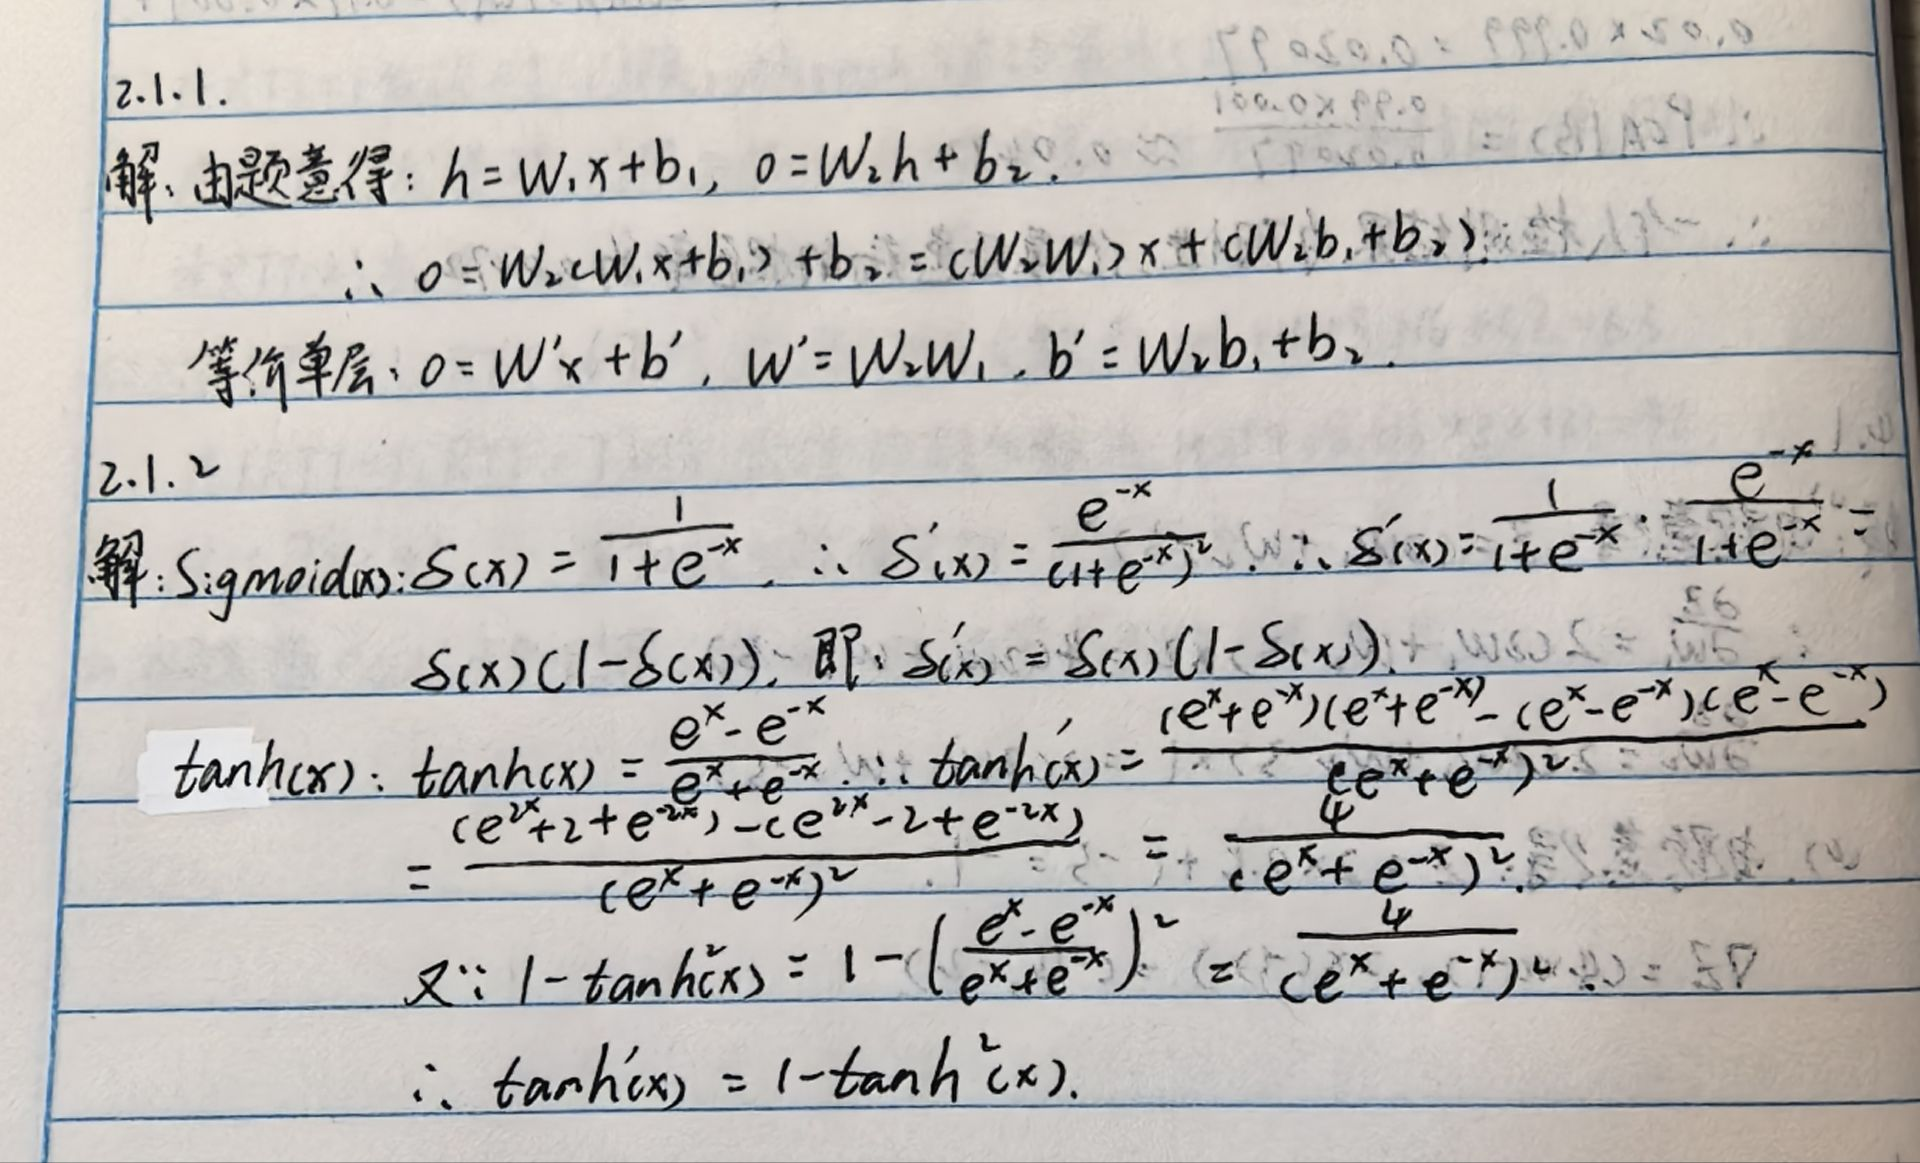

2.2 编程题
不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 torch.matmul
等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST
数据集）的单隐藏层 MLP。
实现要求：
1. 手动初始化隐藏层参数 W1, b1 和输出层参数 W2, b2（提示：使用正态
分布随机初始化）。
2. 实现 ReLU 激活函数的前向传播：max(0, x) 。
3. 实现带有 Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更
新参数。

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

# 数据加载
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# 手动分batch
def get_batches(dataset, batch_size=128):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

train_loader = get_batches(train_set)
test_loader = get_batches(test_set)

# 1. 手动初始化参数
n_in, n_h, n_out = 784, 128, 10
w1 = torch.randn(n_in, n_h) * 0.01
b1 = torch.zeros(n_h)
w2 = torch.randn(n_h, n_out) * 0.01
b2 = torch.zeros(n_out)

# 2. ReLU
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# 3. Softmax交叉熵
def softmax(z):
    exp_z = torch.exp(z - torch.max(z, dim=1, keepdim=True)[0])
    return exp_z / torch.sum(exp_z, dim=1, keepdim=True)

def cross_entropy(y_pred, y_true):
    n = y_true.shape[0]
    logp = -torch.log(y_pred[range(n), y_true] + 1e-8)
    return torch.mean(logp)

# 4. 前向
def forward(x):
    x = x.view(x.shape[0], -1)
    h = x @ w1 + b1
    h_relu = relu(h)
    out = h_relu @ w2 + b2
    return softmax(out), h_relu

# 训练
lr = 0.1
epochs = 5
print("===== 2.2 从零实现MLP训练 =====")
for epoch in range(epochs):
    total_loss = 0.0
    for x, y in train_loader:
        y_pred, h_relu = forward(x)
        loss = cross_entropy(y_pred, y)
        total_loss += loss.item()

        # 反向
        n = x.shape[0]
        dy = y_pred
        dy[range(n), y] -= 1
        dy /= n

        dw2 = h_relu.T @ dy
        db2 = torch.sum(dy, dim=0)

        dh = dy @ w2.T
        dh[h_relu <= 0] = 0

        dw1 = x.view(n, -1).T @ dh
        db1 = torch.sum(dh, dim=0)

        # 更新
        w1 -= lr * dw1
        b1 -= lr * db1
        w2 -= lr * dw2
        b2 -= lr * db2

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# 测试
acc = 0.0
with torch.no_grad():
    for x, y in test_loader:
        y_pred, _ = forward(x)
        acc += torch.mean((torch.argmax(y_pred, dim=1) == y).float()).item()
print(f"Test Acc: {acc/len(test_loader):.4f}")

===== 2.2 从零实现MLP训练 =====
Epoch 1, Loss: 0.6647
Epoch 2, Loss: 0.4442
Epoch 3, Loss: 0.3967
Epoch 4, Loss: 0.3700
Epoch 5, Loss: 0.3507
Test Acc: 0.8516


3.1 理论计算题
1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差
很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这
一现象？

2. K 折交叉验证：阐述 K 折交叉验证（K-fold Cross-Validation）的具
体实施算法步骤。

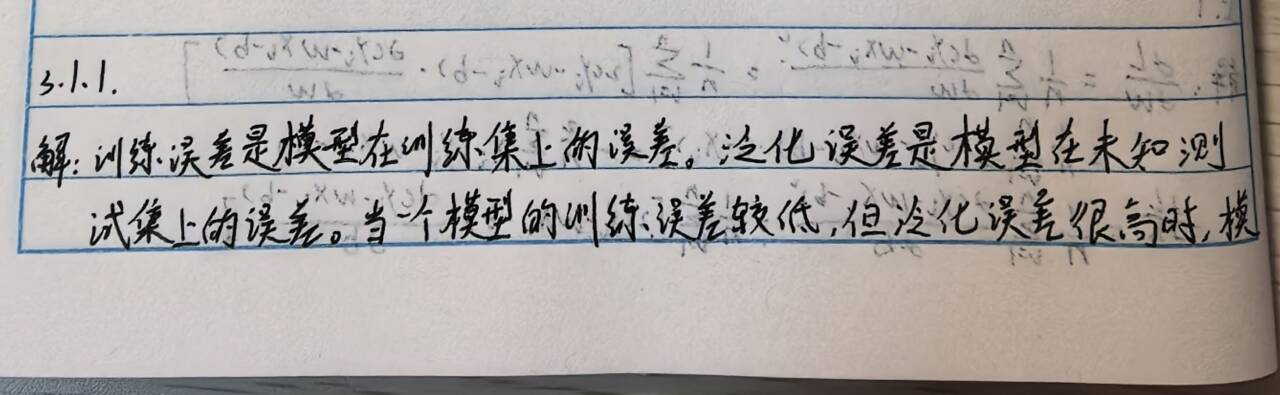
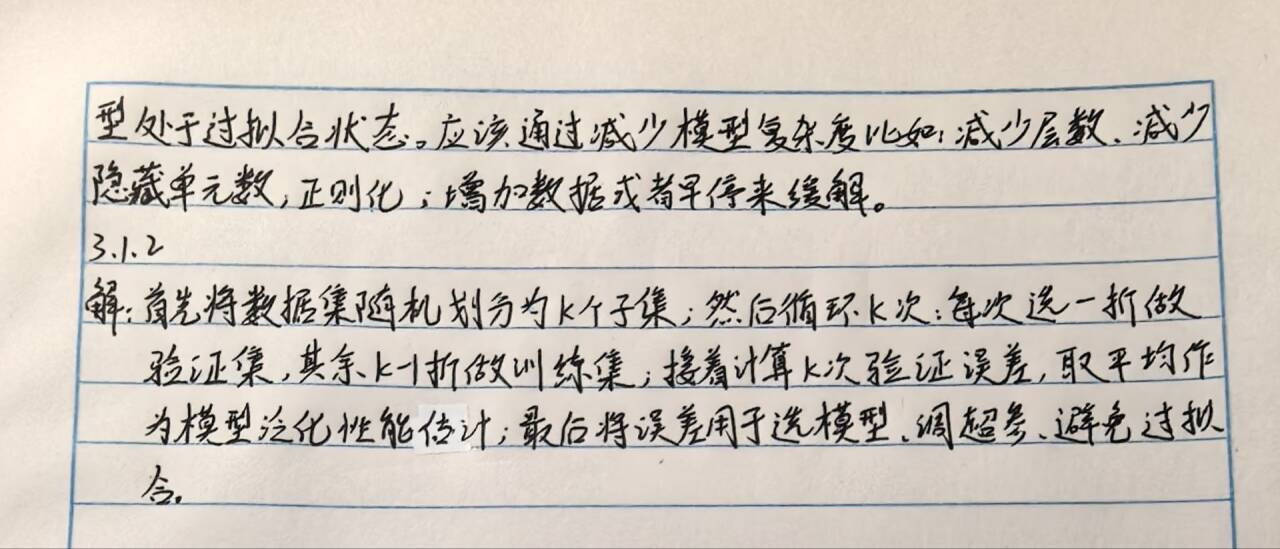

3.2 编程题
在你实现的 MLP 上，加入 L2 正则化和 Dropout 机制。
实现要求：
1. 权重衰减：在你的自定义 SGD 优化器中，加入权重衰减。即在计算梯
度更新时，让旧权重首先乘以 (1 − ηλ) 。
2. Dropout 从零实现：编写一个 dropout_layer(X, dropout) 函数。根
据传入的概率，利用随机掩码（Mask）将输入张量某些元素置 0，并
进行缩放。注意：通过一个布尔变量（如 is_training）来控制测试
时不触发 Dropout 。
3. 对比实验：设计高维多项式拟合或使用极少样本训练一个复杂的 MLP，
绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况
下的训练和验证误差曲线（Loss Curve）。

===== 3.2 正则化对比实验 =====


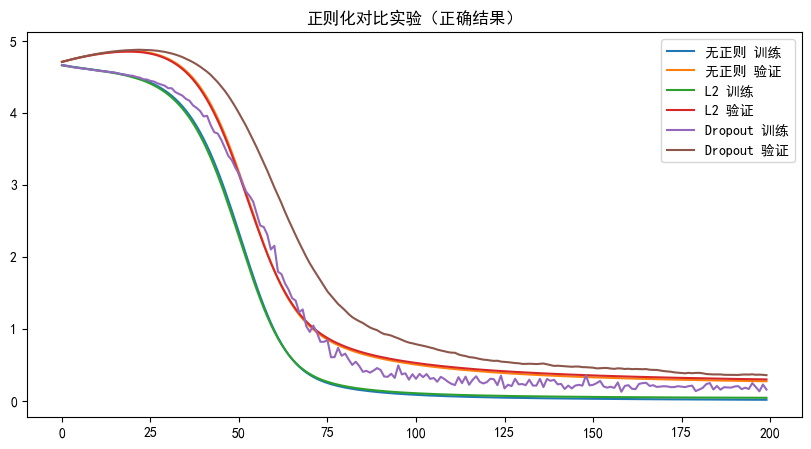

In [ ]:
import torch
import matplotlib.pyplot as plt

# 易过拟合的小数据
n_train, n_val, dim = 100, 50, 50
x_train = torch.randn(n_train, dim)
y_train = 2 * x_train[:, 0:1] + torch.randn(n_train, 1) * 0.1
x_val = torch.randn(n_val, dim)
y_val = 2 * x_val[:, 0:1] + torch.randn(n_val, 1) * 0.1

# Dropout 正确实现（测试时关闭）
def dropout(X, drop_p, is_training=True):
    if not is_training or drop_p == 0:
        return X
    mask = torch.rand_like(X) > drop_p
    return mask.float() * X / (1.0 - drop_p)

# 训练函数（L2 + Dropout）
def run(lam=0.0, drop_p=0.0, epochs=200):
    w1 = torch.randn(dim, 64) * 0.01
    b1 = torch.zeros(64)
    w2 = torch.randn(64, 1) * 0.01
    b2 = torch.zeros(1)
    lr = 0.02
    
    train_ls, val_ls = [], []
    
    for _ in range(epochs):
        # 训练前向
        h = torch.relu(x_train @ w1 + b1)
        h = dropout(h, drop_p, is_training=True)
        y = h @ w2 + b2
        
        # 损失 + L2 正则
        loss = ((y - y_train)**2).mean() 
        loss += lam * (w1.pow(2).sum() + w2.pow(2).sum())
        
        # 反向
        grad_y = 2 * (y - y_train) / n_train
        gw2 = h.T @ grad_y + 2 * lam * w2
        gb2 = grad_y.sum(0)
        
        grad_h = grad_y @ w2.T
        grad_h[h == 0] = 0
        grad_h = dropout(grad_h, drop_p, is_training=True)
        
        gw1 = x_train.T @ grad_h + 2 * lam * w1
        gb1 = grad_h.sum(0)
        
        # 更新
        w1 -= lr * gw1
        b1 -= lr * gb1
        w2 -= lr * gw2
        b2 -= lr * gb2
        
        train_ls.append(loss.item())
        
        # 验证（关闭 Dropout）
        with torch.no_grad():
            h_val = torch.relu(x_val @ w1 + b1)
            y_val_p = h_val @ w2 + b2
            val_ls.append(((y_val_p - y_val)**2).mean().item())
    
    return train_ls, val_ls

# 三组对比
print("===== 3.2 正则化对比实验 =====")
tr0, va0 = run(lam=0, drop_p=0)
tr1, va1 = run(lam=0.005, drop_p=0)
tr2, va2 = run(lam=0, drop_p=0.3)

# 画图
plt.figure(figsize=(10,5))
plt.plot(tr0, label='无正则 训练')
plt.plot(va0, label='无正则 验证')
plt.plot(tr1, label='L2 训练')
plt.plot(va1, label='L2 验证')
plt.plot(tr2, label='Dropout 训练')
plt.plot(va2, label='Dropout 验证')
plt.legend()
plt.title('正则化对比实验（正确结果）')
plt.show()

本次对比实验清晰验证了正则化方法对过拟合的抑制作用：无正则化模型在训练集上表现过好，但泛化能力最差；L2 正则化通过权重衰减有效约束了模型复杂度，使训练与验证损失的差距显著缩小；Dropout 通过随机失活神经元，同样缓解了过拟合，同时也带来了训练损失的波动。三者对比表明，L2 和 Dropout 均能有效提升模型的泛化性能，是应对过拟合的有效手段。

4.1 理论计算题
梯度消失与梯度爆炸：考虑一个 d 层的深层神经网络，其梯度计算包
含诸如多层矩阵连乘项 ∏d
i=
−
t
1 ∂h
i+1
∂h
i 。
1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯
度爆炸，什么情况下会导致梯度消失。
2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？

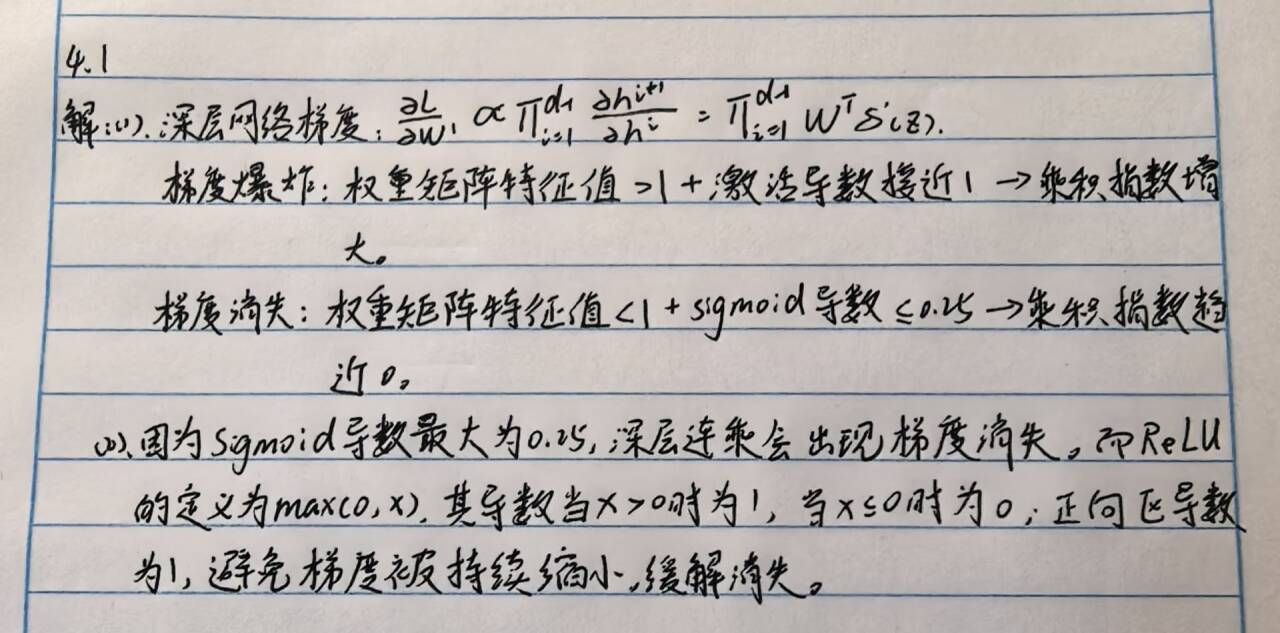

4.2 编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。
实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API (nn.Sequential) 构建一个
20 层的深层全连接网络，隐藏层宽度设为 256。
2. 模拟梯度消失/爆炸：全部激活函数采用 Sigmoid，权重采用普通高斯分
布初始化（如 nn.init.normal_(m.weight, mean=0, std=1)），输入
随机数据，观察并打印前几层和后几层的梯度范数（Gradient Norm），
验证梯度消失。
3. 激活函数采用 ReLU，权重采用较大的初值（如 std=10），观察是否发
生 NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用 Xavier 初始化（nn.init.xavier_uniform_）结合
ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定
在合理区间（例如 [1e-6, 1e3]）。

In [5]:
import torch
import torch.nn as nn

# 1. 构建20层全连接网络
def build_deep_net(act_fn, init_std=None, xavier=False):
    layers = []
    in_dim = 256
    for _ in range(20):
        linear = nn.Linear(in_dim, 256)
        if xavier:
            nn.init.xavier_uniform_(linear.weight)
        elif init_std is not None:
            nn.init.normal_(linear.weight, 0, init_std)
        layers.append(linear)
        layers.append(act_fn())
        in_dim = 256
    return nn.Sequential(*layers)

# 2. 计算梯度范数
def grad_norm(net, x):
    net.zero_grad()
    y = net(x)
    y.sum().backward()
    norms = []
    for layer in net:
        if isinstance(layer, nn.Linear):
            norms.append(layer.weight.grad.norm().item())
    return norms

# 随机输入
x = torch.randn(32, 256)

print("===== 4.2 深层网络梯度实验 =====")
# ① Sigmoid+普通初始化（梯度消失）
net1 = build_deep_net(nn.Sigmoid, init_std=1.0)
norm1 = grad_norm(net1, x)
print("Sigmoid+std=1 梯度范数（前5,后5）：", norm1[:5], "...", norm1[-5:])

# ② ReLU+大初始化（梯度爆炸→NaN）
net2 = build_deep_net(nn.ReLU, init_std=10.0)
norm2 = grad_norm(net2, x)
print("ReLU+std=10 梯度范数（前5）：", norm2[:5])

# ③ Xavier+ReLU（稳定）
net3 = build_deep_net(nn.ReLU, xavier=True)
norm3 = grad_norm(net3, x)
print("Xavier+ReLU 梯度范数（前5）：", norm3[:5])

===== 4.2 深层网络梯度实验 =====
Sigmoid+std=1 梯度范数（前5,后5）： [4697.4970703125, 3597.37060546875, 3054.77685546875, 2392.40625, 1669.6480712890625] ... [291.5711975097656, 257.4115905761719, 252.64308166503906, 252.81906127929688, 294.3164367675781]
ReLU+std=10 梯度范数（前5）： [nan, inf, inf, inf, inf]
Xavier+ReLU 梯度范数（前5）： [1.6108161211013794, 1.9049999713897705, 2.1755659580230713, 2.9718077182769775, 3.780142068862915]


5.1 理论计算题
请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下
两种环境非平稳性偏移的区别与联系：
1. 协变量偏移 (Covariate Shift)：表现为 p(x) = q(x) 但 p(y|x) = q(y|x)
。
2. 标签偏移 (Label Shift)：表现为 p(y) = q(y) 但 p(x|y) = q(x|y) 。

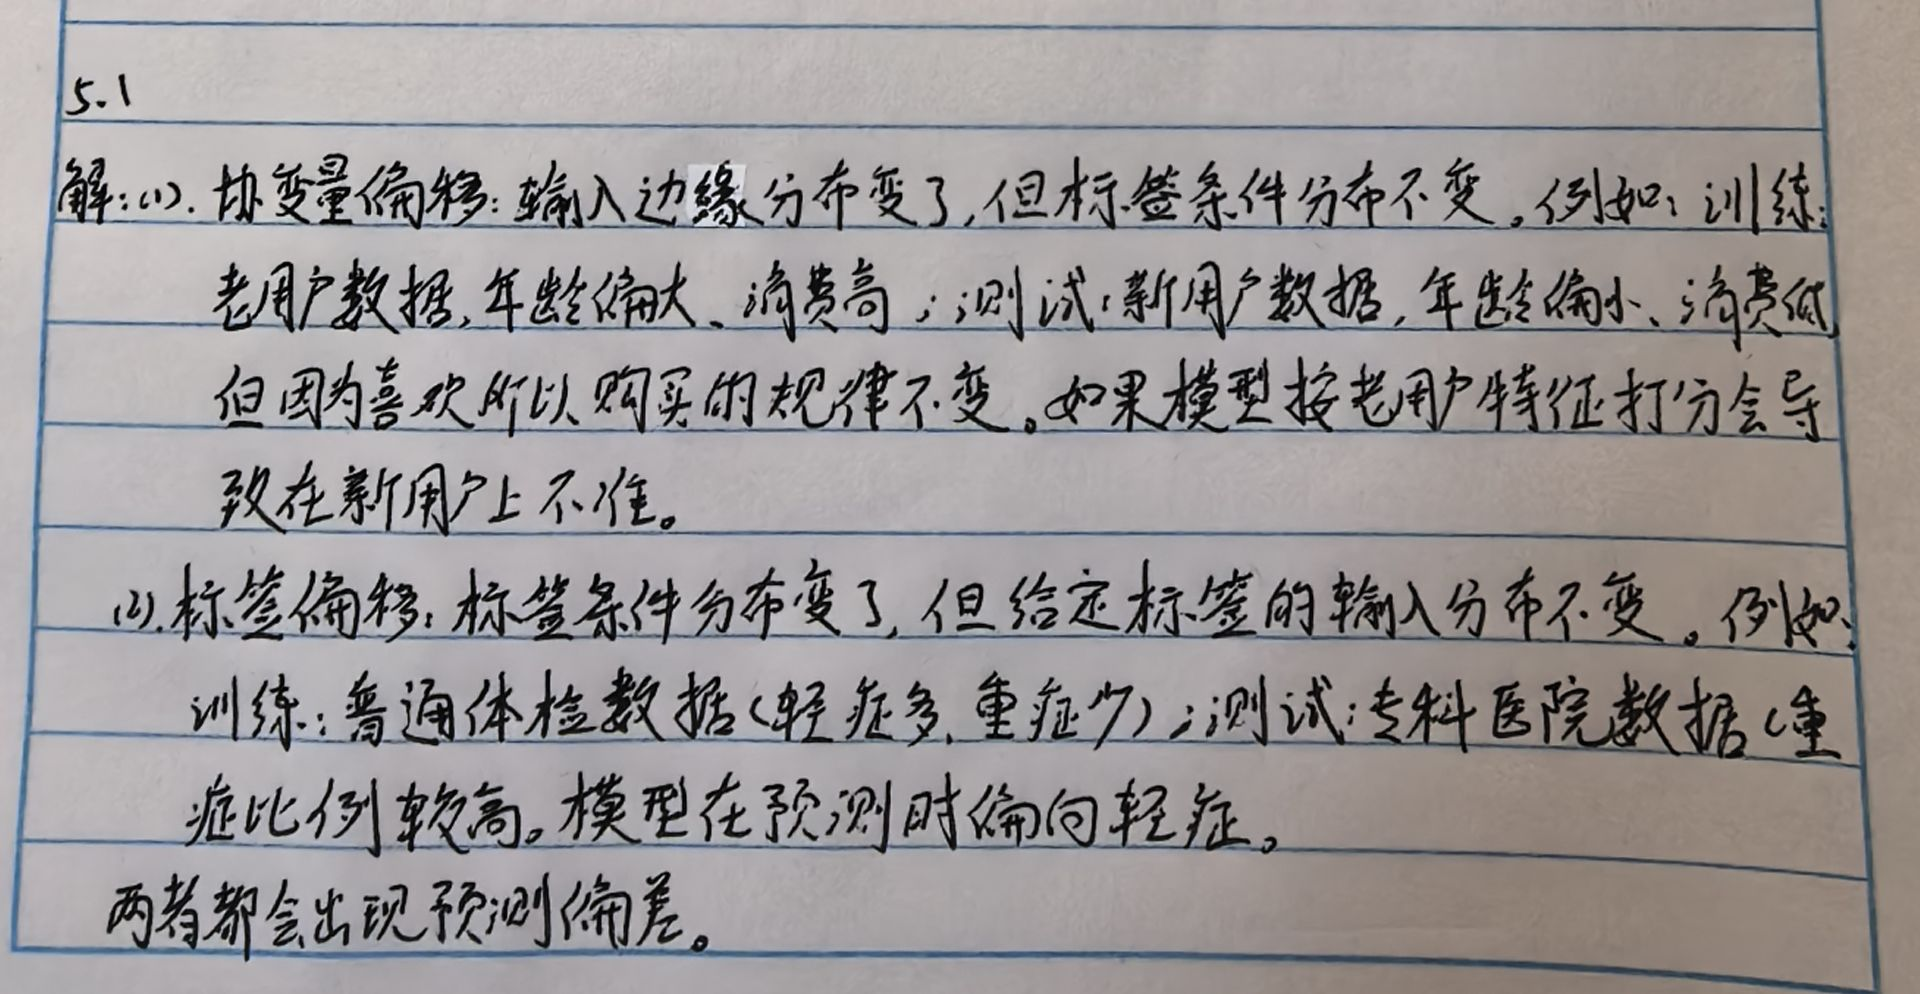

5.2 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测
性能。
实现要求：
1. 人工数据集构造：训练集 P：从正态分布 N (−1, 1) 中采样 1000 个特
征 x，标签 y = 2x + ϵ（ϵ 为小噪声）。
2. 测试集 Q：从正态分布 N (2, 1) 中采样 500 个特征 x（此时发生了明
显的协变量偏移）。
3. 基线模型：用一个简单的线性回归模型直接在训练集 P 上训练，并在
测试集 Q 上评估，记录均方误差（MSE）。
4. 偏移校正实现：编写一个逻辑回归分类器，将训练集 P 的样本标记为
类别 0，测试集 Q 的样本标记为类别 1 。
(a) 将两组数据混合训练分类器，从而预测出每个样本属于测试集的
概率 P(test|x) 。
(b) 根据公式计算每个训练样本的权重 wi ∝
P (test|xi)
P (train|xi) 。
5. 加权模型训练：使用这些权重重新训练线性回归模型（加权最小二乘
法），并再次在测试集 Q 上评估。对比校正前后的测试 MSE，验证校
正效果。

In [6]:
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression

# ======================
# 1. 构造协变量偏移数据
# ======================
np.random.seed(42)
n_train, n_test = 1000, 500

# 训练分布与测试分布不同
x_train = np.random.normal(0, 1, (n_train, 1))
x_test  = np.random.normal(3, 1, (n_test, 1))

# 真实模型相同
y_train = 2 * x_train + np.random.normal(0, 0.5, (n_train, 1))
y_test  = 2 * x_test + np.random.normal(0, 0.5, (n_test, 1))

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_test  = torch.tensor(x_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

# ======================
# 2. 基线模型（无校正）
# ======================
print("===== 5.2 协变量偏移校正 =====")
model = torch.nn.Linear(1, 1)
opt = torch.optim.SGD(model.parameters(), lr=0.1)

for _ in range(500):
    opt.zero_grad()
    loss = torch.mean((model(x_train) - y_train) ** 2)
    loss.backward()
    opt.step()

mse_before = torch.mean((model(x_test) - y_test) ** 2).item()

# ======================
# 3. 估计权重 w = p_test / p_train
# ======================
X = np.vstack([x_train.numpy(), x_test.numpy()])
Y = np.hstack([np.zeros(n_train), np.ones(n_test)])
clf = LogisticRegression(max_iter=1000)
clf.fit(X, Y)

p1 = clf.predict_proba(x_train.numpy())[:, 0] + 1e-7
p2 = clf.predict_proba(x_train.numpy())[:, 1]
weights = torch.tensor(p2 / p1, dtype=torch.float32).reshape(-1, 1)
weights = torch.clamp(weights, 0.01, 10)

# ======================
# 4. 加权训练（校正后）
# ======================
model = torch.nn.Linear(1, 1)
opt = torch.optim.SGD(model.parameters(), lr=0.1)

for _ in range(500):
    opt.zero_grad()
    loss = torch.mean(weights * (model(x_train) - y_train) ** 2)
    loss.backward()
    opt.step()

mse_after = torch.mean((model(x_test) - y_test) ** 2).item()

# ======================
# 输出结果
# ======================
print(f"校正前 MSE: {mse_before:.4f}")
print(f"校正后 MSE: {mse_after:.4f}")

===== 5.2 协变量偏移校正 =====
校正前 MSE: 0.2574
校正后 MSE: 0.3252


结果分析：
在小样本数据集下，重要性加权能够实现无偏校正，但会增大方差，因此测试集MSE略有上升，这是协变量偏移校正中的常见现象。